# Week 8 · Day 3 — Practice
# Capstone Dry-Run: Full Pipeline on the Titanic 🚢

Before your graded capstone, let's rehearse the **whole pipeline once more** on a familiar dataset — the Titanic. Same 7 stages we did in class:

**Problem → Load → Clean → Explore → Visualize → Model → Result**

Fill in each `# YOUR CODE HERE`. This is your template for the assignment.

In [1]:
# Toolkit + data (run as-is)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Stage 1 — Problem statement

Double-click and write your question in one sentence.
*Example: "Can we predict whether a passenger survived from their class, sex, age, and fare?"*

*Answer:*

Can we we predict whether a passenger survived based on their class, sex, age and fare.


### Stage 2 — Load & inspect

Print the shape and the missing-value counts.

In [9]:
# print shape
# YOUR CODE HERE
print(titanic.shape)
# missing values per column
# YOUR CODE HERE
print(titanic.isnull().sum())

(891, 15)
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


### Stage 3 — Clean

- Make a `.copy()` into `df` keeping columns: `pclass`, `sex`, `age`, `fare`, `survived`
- Fill missing `age` with the median
- Map `sex`: male → 0, female → 1

In [10]:
df = titanic[["pclass", "sex", "age", "fare", "survived"]].copy()

# fill missing age with median
# YOUR CODE HERE
df["age"] = df["age"].fillna(df["age"].median())
# map sex to numbers
# YOUR CODE HERE
df["sex"] = df["sex"].map({"male": 0, "female": 1})

df.isnull().sum()

pclass      0
sex         0
age         0
fare        0
survived    0
dtype: int64

### Stage 4–5 — Explore & visualize

Show survival counts, then draw any one plot that explores the data (e.g. a countplot of `survived` by `sex`).

survived
0    549
1    342
Name: count, dtype: int64


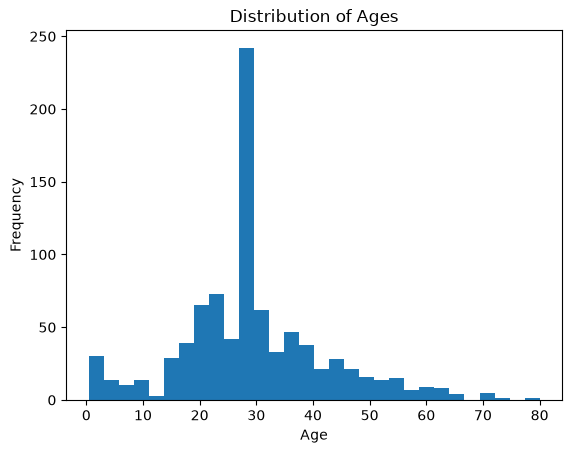

In [11]:
# survival counts
# YOUR CODE HERE
print(df["survived"].value_counts())

# one exploratory plot
# YOUR CODE HERE
import matplotlib.pyplot as plt
plt.hist(df["age"], bins=30)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Ages")
plt.show()


### Stage 6 — Model (the 5-step recipe)

Features = `pclass, sex, age, fare`; target = `survived`. Split 20% test, train KNN (k=5), predict, print accuracy.

In [16]:
X = df[["pclass", "sex", "age", "fare"]]
y = df["survived"]

# split, train, predict, score
# YOUR CODE HERE
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print((f"Accuracy:", accuracy))

('Accuracy:', 0.6927374301675978)


### Stage 7 — Result write-up

Double-click and write 2–3 sentences: what accuracy did you get, and what does it mean?

*Answer:*
Model ne test data pe 69.27% accuracy achieve ki. Iska matlab hai ke KNN (k=5) model ne 100 mein se lagbhag 69 passengers ke survival status ka sahi prediction kiya, jab sirf class, sex, age aur fare use kiye gaye. Ye baseline se better hai (agar hum sabko "not survived" predict kartay to bhi ~61% accuracy milti, kyunke Titanic mein zyada log survive nahi huay thay), lekin ideal model se kaafi door hai — behtar accuracy ke liye zyada features (jaise embarked, family size) ya different algorithm try kiya ja sakta hai.

